In [1]:
import os, yaml, sys
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import networkx as nx
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, RSA, load_img_natraster, print_wise, TimeSeries, get_relevant_output_layers
from general_utils.dRSA import across_areas_dRSA
from general_utils.II import InformationImbalance, compare_similarity_metrics

In [29]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'baby1'
    date: str = '220226to527' # '250313' #  #  # # "230204"#'240816to26'
    brain_area: str = 'AIT'
    k=20
    new_fs: int = 100 # Hz
    model_name: str = 'vit_l_16'
    layer_name: str = 'blocks.16.mlp.fc2'
    img_size: int = 384
    pooling: str = 'mean'
    pkg: str = 'timm'
    folder_name = 'talia_20each_tizi'

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
brain_areas = ['V1', 'V2', 'V3', 'PIT', 'CIT', 'AIT']

In [30]:

feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{layers[0]}_features_{cfg.pooling}pool.npz"
feats = np.load(feats_filename)["arr_0"]
ii_obj = InformationImbalance("euclidean", "euclidean", k=cfg.k)
ii_obj.compute_RDM(feats, 'signal')
ii_obj.compute_distance_ranks('signal')
tot_A2B = []
tot_B2A = []
for i, l in enumerate(layers):
    feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{l}_features_{cfg.pooling}pool.npz"
    target_feats = np.load(feats_filename)["arr_0"]
    ii_obj.compute_RDM(target_feats, "model")
    ii_obj.compute_distance_ranks('model')
    A2B, B2A = ii_obj.compute_both_II()
    tot_A2B.append(A2B)
    tot_B2A.append(B2A)



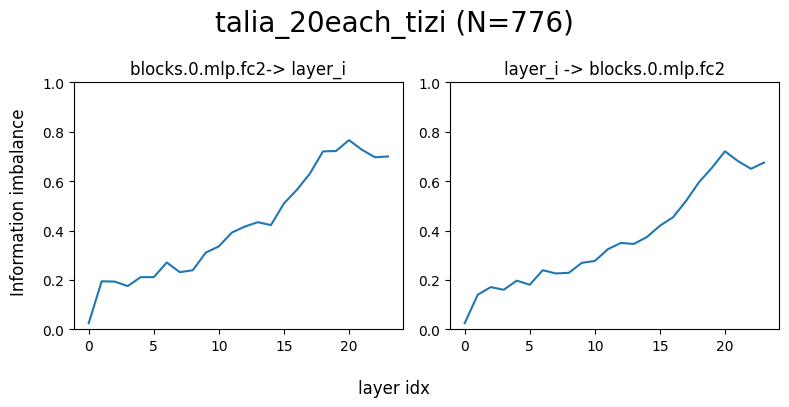

In [32]:
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].plot(tot_A2B)
ax[1].plot(tot_B2A)
ax[0].set_title(f"{layers[0]}-> layer_i")
ax[1].set_title(f"layer_i -> {layers[0]}")
fig.supylabel("Information imbalance")
fig.supxlabel("layer idx")
ax[0].set_ylim([0,1])
ax[1].set_ylim([0,1])
fig.suptitle(f"{cfg.folder_name} (N={feats.shape[1]})", fontsize=20)
plt.tight_layout()